# 文本聚类和主题建模

# 文本聚类和主题建模

尽管监督技术（如分类）过去几年在业界占据主导地位，但像文本聚类这样的无监督技术的潜力也不容小觑。

文本聚类旨在基于文本的语义内容、含义和关系对相似文本进行分组。如图5-1所示，将语义相似的文档聚类成簇，不仅可以高效地分类大量非结构化文本，还能实现快速的探索性数据分析。

<div align="center">
    <img src="./picture/5-1.jpg">
    <p>图5-1：非结构化文本数据聚类</p>
</div>

近年来语言模型的发展使文本的上下文和语义表示成为可能，这提升了文本聚类的效果。语言不仅仅是词袋，最新的语言模型已经证明，它们能够很好地捕捉语言的上下文和语义概念。文本聚类不受监督的约束，可以实现创造性的解决方案和多样化的应用，如寻找离群点、加速标注和发现标注错误的数据。

文本聚类也在主题建模领域，即我们希望在大量文本数据集合中发现（抽象的）主题时发挥作用。如图5-2所示，我们通常使用关键词或关键短语来描述主题，理想情况下会有一个总体的概括性标签。

<div align="center">
    <img src="./picture/5-2.jpg">
    <p>图5-2：主题建模是一种为文本文档簇赋予含义的方法</p>
</div>

在本章中，我们将首先探索如何使用嵌入模型进行聚类，然后过渡到一种受文本聚类启发的主题建模方法，即BERTopic。

文本聚类和主题建模在本书中扮演着重要角色，因为它们探索了结合各种语言模型的创新方法。我们将探索如何将仅编码器（嵌入）​、仅解码器（生成）甚至经典方法（词袋）结合起来，从而产生令人惊叹的新技术和新流程。

## 5.1 ArXiv文章：计算与语言

在本章中，我们将在ArXiv文章上运行聚类和主题建模算法。ArXiv是一个主要面向计算机科学、数学和物理领域的开放的学术文章平台。为了与本书主题保持一致，我们将探索计算与语言领域的文章。arxiv_nlp这一数据集包含1991年至2024年间来自ArXiv cs.CL（计算与语言）板块的44949篇摘要。

我们加载数据，并为每篇文章的摘要、标题和年份创建单独的变量：

In [1]:
# 从Hugging Face加载数据
from datasets import load_dataset
dataset = load_dataset("maartengr/arxiv_nlp", cache_dir="data")["train"]
# 提取元数据
abstracts = dataset["Abstracts"]
titles = dataset["Titles"]

'[WinError 10060] 由于连接方在一段时间后没有正确答复或连接的主机没有反应，连接尝试失败。' thrown while requesting HEAD https://huggingface.co/datasets/maartengr/arxiv_nlp/resolve/b56743e671f49880a17b7fab44b02f1df32fcaff/arxiv_nlp.py
Retrying in 1s [Retry 1/5].
'[WinError 10060] 由于连接方在一段时间后没有正确答复或连接的主机没有反应，连接尝试失败。' thrown while requesting HEAD https://huggingface.co/datasets/maartengr/arxiv_nlp/resolve/b56743e671f49880a17b7fab44b02f1df32fcaff/arxiv_nlp.py
Retrying in 2s [Retry 2/5].
'[WinError 10060] 由于连接方在一段时间后没有正确答复或连接的主机没有反应，连接尝试失败。' thrown while requesting HEAD https://huggingface.co/datasets/maartengr/arxiv_nlp/resolve/b56743e671f49880a17b7fab44b02f1df32fcaff/arxiv_nlp.py
Retrying in 4s [Retry 3/5].
'[WinError 10060] 由于连接方在一段时间后没有正确答复或连接的主机没有反应，连接尝试失败。' thrown while requesting HEAD https://huggingface.co/datasets/maartengr/arxiv_nlp/resolve/b56743e671f49880a17b7fab44b02f1df32fcaff/arxiv_nlp.py
Retrying in 8s [Retry 4/5].
'[WinError 10060] 由于连接方在一段时间后没有正确答复或连接的主机没有反应，连接尝试失败。' thrown while requesting HEAD https://hugg

## 5.2 文本聚类的通用流程

文本聚类不仅可以发现已知的数据模式，更可以挖掘不为人知的数据模式。它可以帮助你直观地理解任务（如分类任务）及其复杂性。因此，文本聚类的应用范围广阔，不仅限于快速、探索性的数据分析。

虽然文本聚类的方法有很多，从基于图的神经网络到基于质心的聚类技术，但当前比较流行的通用流程主要包含以下三个步骤（每一步对应一种算法）​：

第一步，使用嵌入模型(embedding model)将输入文档转换为嵌入向量；

第二步，使用降维模型(dimensionality reduction model)将嵌入向量降至更低维度空间；

第三步，使用聚类模型(cluster model)对降维后的嵌入向量进行聚类。

5.2.1 嵌入文档

第一步是将我们的文本数据转换为嵌入向量，如图5-3所示。回顾前几章的内容，嵌入向量是试图捕捉文本含义的数值表示。

<div align="center">
    <img src="./picture/5-3.jpg">
    <p>图5-3：第一步，使用嵌入模型将输入文档转换为嵌入向量</p>
</div>


选择为语义相似度任务优化的嵌入模型对聚类任务特别重要，因为我们是在寻找语义相似的一组文档。幸运的是，在撰写本书时，大多数嵌入模型专注于语义相似度。

与上一章一样，我们将使用MTEB排行榜来选择嵌入模型。我们需要一个在聚类任务上表现不错且足够小，能快速运行的嵌入模型。这次我们不使用上一章中的sentence-transformers/all-mpnet-base-v2模型，而是选择thenlper/gte-small模型。这是一个较新的模型，在聚类任务上的表现优于前者，而且由于体积小，推理速度更快。当然，你也可以随意尝试其他新近发布的模型。

In [2]:
from sentence_transformers import SentenceTransformer
# 为每个摘要创建嵌入向量
embedding_model = SentenceTransformer("../models/gte-small")
embeddings = embedding_model.encode(abstracts, show_progress_bar=True)

W1006 14:49:07.748000 38880 Lib\site-packages\torch\utils\flop_counter.py:113] triton not found; flop counting will not work for triton kernels


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/1405 [00:00<?, ?it/s]

检查一下每个文档嵌入包含多少个值：

In [3]:
# 检查生成的嵌入向量的维度
embeddings.shape

(44949, 384)

每个嵌入向量包含384个值，这些值共同构成了文档的语义表示。你可以将这些嵌入向量视为我们要进行聚类的特征。

## 5.2.2 嵌入向量降维

在进行聚类之前，首先需要考虑嵌入向量的高维特性。随着维度的增加，每个维度中可能的取值数量呈指数级增长，在每个维度中寻找所有子空间变得越来越复杂。

因此，高维数据对许多聚类技术来说是一个难题，因为识别有意义的聚类变得更加困难。我们可以通过降维来解决这个问题。如图5-4所示，降维技术允许我们减小维度空间的大小，用更少的维度来表示相同的数据。降维技术的目标是通过寻找低维表示来保持高维数据的全局结构。

<div align="center">
    <img src="./picture/5-4.jpg">
    <p>图5-4：降维是将高维空间中的数据压缩为低维表示</p>
</div>

请注意，降维是一种压缩技术，其底层算法并不是随意删除维度这么简单。为了帮助聚类模型更高效地创建有意义的簇，如图5-5所示，我们的聚类流程中的第二步采用了降维处理。

<div align="center">
    <img src="./picture/5-5.jpg">
    <p>图5-5：第二步，通过降维将嵌入向量降至更低维度空间</p>
</div>

主成分分析(Principal Component Analysis，PCA)以及统一流形逼近和投影(Uniform Manifold Approximation andProjection，UMAP)是著名的降维方法。对于这个流程，我们选择使用UMAP，因为它在处理非线性关系和结构方面比PCA表现更好。

需要注意的是，降维技术并非完美无缺。它们无法完美地将高维数据压缩到低维表示中。这个过程总是会损失一些信息。因此，需要在降维和保留尽可能多的信息之间找到平衡点。

要执行降维，需要实例化UMAP类并将生成的嵌入向量传递给它：

In [4]:
from umap import UMAP
# 将输入嵌入向量从384维降至5维
umap_model = UMAP(
    n_components=5, min_dist=0.0, metric="cosine", random_state=42
)
reduced_embeddings = umap_model.fit_transform(embeddings)

d:\study\python\AiAgent\图解大模型\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


我们可以使用n_components参数来决定低维空间的形状，这里设为5维。通常，5和10之间的值能很好地捕捉高维全局结构。

min_dist参数是嵌入点之间的最小距离。我们将其设为0，通常这会产生更紧密的簇。我们将metric设置为"cosine"，因为基于欧氏距离的方法在处理高维数据时会遇到问题。

请注意，在UMAP中设置random_state将使结果在不同会话中可重现，但会禁用并行处理，因此会导致训练速度变慢。

### 5.2.3 对降维后的嵌入向量进行聚类

如图5-6所示，第三步是对降维后的嵌入向量进行聚类。

<div align="center">
    <img src="./picture/5-6.jpg">
    <p>图5-6：第三步，使用降维后的嵌入向量进行文档聚类</p>
</div>

虽然我们通常选择像k均值聚类(k-means)这样的基于质心的算法，但它需要生成一组预设的簇，而我们事先并不知道簇的数量。而基于密度的算法可以自由计算簇的数量，并且不会强制所有数据点属于某个簇，如图5-7所示。

<div align="center">
    <img src="./picture/5-7.jpg">
    <p>图5-7：聚类算法不仅影响簇的生成方式，还影响簇的呈现方式</p>
</div>

一个常见的基于密度的算法是HDBSCAN（HierarchicalDensity-Based Spatial Clustering of Applications withNoise，具有噪声的分层密度空间聚类）。HDBSCAN是聚类算法DBSCAN的层次化变体，它无须显式指定簇的数量就能发现密集的（微型）簇。作为一种基于密度的方法，HDBSCAN还可以检测数据中的离群点，即不属于任何簇的数据点。这些离群点不会被分配或强制归属于任何簇，换句话说，它们会被忽略。由于ArXiv文章可能包含一些小众论文，使用能够检测离群点的模型可能会很有帮助。

与之前的包一样，使用HDBSCAN也很简单。我们只需要实例化模型，并将降维后的嵌入向量传递给它：

In [5]:
from hdbscan import HDBSCAN
# 拟合模型并提取簇
hdbscan_model = HDBSCAN(
    min_cluster_size=50, metric="euclidean", cluster_selection_method="eom"
).fit(reduced_embeddings)
clusters = hdbscan_model.labels_
# 我们生成了多少个簇？
len(set(clusters))

159

使用HDBSCAN，我们在数据集中生成了159个簇。要创建更多簇，需要减小min_cluster_size的值，它代表一个簇的最小规模。

### 5.2.4 检查生成的簇现

在我们已经生成了簇，可以手动检查每个簇并探索每个簇中分配的文档，以了解其内容。例如，从簇0中随机抽取几个文档：

In [6]:
import numpy as np
# 打印簇0中的前三个文档
cluster = 0
for index in np.where(clusters==cluster)[0][:3]:
    print(abstracts[index][:300] + "... \n")

  This works aims to design a statistical machine translation from English text
to American Sign Language (ASL). The system is based on Moses tool with some
modifications and the results are synthesized through a 3D avatar for
interpretation. First, we translate the input text to gloss, a written fo... 

  Researches on signed languages still strongly dissociate lin- guistic issues
related on phonological and phonetic aspects, and gesture studies for
recognition and synthesis purposes. This paper focuses on the imbrication of
motion and meaning for the analysis, synthesis and evaluation of sign lang... 

  Modern computational linguistic software cannot produce important aspects of
sign language translation. Using some researches we deduce that the majority of
automatic sign language translation systems ignore many aspects when they
generate animation; therefore the interpretation lost the truth inf... 



从打印的文档来看，这个簇似乎主要包含有关手语翻译的文档，很有趣！

我们可以更进一步，尝试可视化结果，这样就不用手动检查所有文档了。为此，我们需要将文档嵌入降至二维，这样就可以在x-y平面上绘制文档：

In [7]:
import pandas as pd
# 将384维的嵌入向量降至二维以便于可视化
reduced_embeddings = UMAP(
    n_components=2, min_dist=0.0, metric="cosine", random_state=42
).fit_transform(embeddings)
# 创建数据框
df = pd.DataFrame(reduced_embeddings, columns=["x", "y"])
df["title"] = titles
df["cluster"] = [str(c) for c in clusters]
# 选择离群点和非离群点（聚类）
clusters_df = df.loc[df.cluster != "-1", :]
outliers_df = df.loc[df.cluster == "-1", :]

d:\study\python\AiAgent\图解大模型\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


我们还分别为簇和离群点创建了数据框（clusters_df和outliers_df）​，通常我们想要关注并突出显示这些簇。

出于可视化目的使用任何降维技术都会造成信息损失，其结果仅仅是原始嵌入向量的一个近似表示。尽管它很有参考价值，但可能会使簇靠得更近或远离其实际位置。因此，人工评估（也就是我们自己检查簇）是聚类分析的关键组成部分！

为了生成静态图，我们将使用广为人知的绘图库matplotlib：

(np.float64(-7.48530650138855),
 np.float64(11.154523611068726),
 np.float64(-0.9123462788760662),
 np.float64(15.865085711330176))

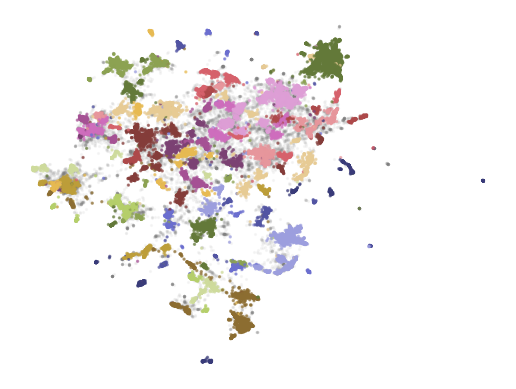

In [8]:
import matplotlib.pyplot as plt
# 分别绘制离群点和非离群点
plt.scatter(outliers_df.x, outliers_df.y, alpha=0.05, s=2, c="grey")
plt.scatter(
    clusters_df.x, clusters_df.y, c=clusters_df.cluster.astype(int),
    alpha=0.6, s=2, cmap="tab20b"
)
plt.axis("off")

结果如图5-8所示，它很好地捕捉到了主要的簇。注意观察那些颜色相同的点，颜色相同表明HDBSCAN将它们分到了同一组。由于我们有大量的簇，绘图库会在簇之间循环使用颜色，所以并非所有绿色的点都属于同一个簇。

<div align="center">
    <img src="./picture/5-8.jpg">
    <p>图5-8：生成的簇（彩色）和离群点（灰色）以二维可视化方式表示</p>
</div>

这种可视化效果很吸引人，但还不足以让我们看到聚类过程内部发生了什么。要扩展这种可视化效果，我们可以从文本聚类转向主题建模。

## 5.3 从文本聚类到主题建模

文本聚类是在大型文档集合中发现结构的有力工具。在之前的例子中，我们可以手动检查每个簇，并根据其文档集合来识别它们。例如，我们分析了一个包含手语相关文档的簇，因此可以说这个簇的主题是“手语”​。

这种在文本数据集合中寻找主题或潜在语义的思路，通常被称为主题建模。如图5-9所示，传统上，主题建模的目标是找到一组最能代表、捕捉主题含义的关键词或短语。

主题建模技术并非将主题标记为“手语”​，而是使用诸如“手势”​“语言”​“翻译”等关键词来描述主题。因此，结果并不是单一的标签，用户需要通过这些关键词来理解主题的含义。

<div align="center">
    <img src="./picture/5-9.jpg">
    <p>图5-9：传统上，主题通过若干关键词来表示，但也可以采用其他形式</p>
</div>

经典方法，如潜在狄利克雷分配(latent Dirichlet allocation，LDA)，假设每个主题都由语料库词表中词的概率分布来表示。图5-10展示了词表中的每个词是如何根据其与每个主题的相关性被评分的。

<div align="center">
    <img src="./picture/5-10.jpg">
    <p>图5-10：关键词是基于它们在单个主题上的分布来提取的</p>
</div>

这些经典方法通常使用词袋技术提取文本数据的主要特征，而没有考虑词和短语的上下文及含义。相比之下，文本聚类示例则考虑了这两方面，因为它依赖基于Transformer的嵌入向量，这种嵌入向量通过注意力机制针对语义相似性和上下文含义进行了优化。

在本节中，我们将通过一个高度模块化的文本聚类和主题建模框架BERTopic，将文本聚类扩展到主题建模领域。

5.3.1 BERTopic：一个模块化主题建模框架

BERTopic是一种主题建模技术，它利用语义相似的文本聚类来提取各种类型的主题表示。BERTopic处理流程可以分为两个部分。

第一部分是聚类。首先，如图5-11所示，我们采用与前面文本聚类示例相同的步骤进行主题建模。我们对文档进行嵌入、降维，最后对降维后的嵌入向量进行聚类，从而创建语义相似的文档组。

<div align="center">
    <img src="./picture/5-11.jpg">
    <p>图5-11：BERTopic处理流程的第一部分是创建语义相似文档的聚类</p>
</div>

其次，它利用经典的词袋方法，对词表中的词在语料库中的分布建模。正如我们在第1章中简要讨论的，词袋模型将文档看作由一组词组成的“袋子”​，统计每个词在文档中出现的次数。由此产生的表示，可以用来提取文档中出现最频繁的那些词。

<div align="center">
    <img src="./picture/5-12.jpg">
    <p>图5-12：用词袋统计每个词在文档中出现的次数</p>
</div>

然而，这里有两个需要注意的问题。其一，这是文档级别的表示，而我们需要的是簇级别的视角。为了解决这个问题，我们统计整个簇中而不是单个文档中的词频，如图5-13所示。

<div align="center">
    <img src="./picture/5-13.jpg">
    <p>图5-13：通过统计每个簇中而不是每个文档中的词频来生成c-TF</p>
</div>

其二，像the和I这样的停用词(stop word)在文档中经常出现，但对文档的实际含义贡献很小。BERTopic使用基于类的词频-逆文档频率(c-TF-IDF)，来提升对单个簇更有意义的词的权重，降低在所有簇中都常用的词的权重。

词袋中的每个词的词频（c-TF-IDF中的c-TF）都要乘以每个词的IDF值。如图5-14所示，IDF值的计算方法是：所有簇中所有词的平均频次(A)除以当前词的总频次([插图])，加上1，再取对数（本书此处及后续取对数操作的底数均为e）​。

<div align="center">
    <img src="./picture/5-14.jpg">
    <p>图5-14：创建权重方案</p>
</div>

结果是每个词的权重(IDF)，我们可以将其与词频(c-TF)相乘得到加权值(c-TF-IDF)。

BERTopic处理流程的第二部分是主题表示。如图5-15所示，此处允许我们生成之前看到的词分布。我们可以使用scikit-learn的CountVectorizer来生成词袋（或词频）表示。在这里，每个簇被视为一个主题，对语料库的词表有特定的排序。

<div align="center">
    <img src="./picture/5-15.jpg">
    <p>图5-15：BERTopic处理流程的第二部分是主题表示：计算词(x)在类(c)中的权重</p>
</div>

将聚类和主题表示这两个部分结合在一起，就形成了完整的BERTopic处理流程，如图5-16所示。通过这个处理流程，我们可以聚类语义相似的文档，并从簇中生成由几个关键词表示的主题。一个词在主题中的权重越高，它就越能代表该主题。

<div align="center">
    <img src="./picture/5-16.jpg">
    <p>图5-16：完整的BERTopic处理流程大致包含聚类和主题表示两个部分</p>
</div>

该处理流程的一个主要优势是，聚类和主题表示这两个部分在很大程度上是相互独立的。例如，使用c-TF-IDF时，我们不依赖于聚类文档时使用的模型。这使得处理流程的每个组件都具有显著的模块化特性。正如我们将在本章后面探讨的那样，这是微调主题表示的绝佳起点。

如图5-17所示，sentence-transformers是默认的嵌入模型，但可以用任何其他嵌入技术替换。这同样适用于所有其他步骤。如果你不想使用HDBSCAN生成离群点，可以使用k均值聚类替代。

<div align="center">
    <img src="./picture/5-17.jpg">
    <p>图5-17：模块化是BERTopic的一个关键特性，允许你按照自己的方式构建主题模型</p>
</div>

你可以把这种模块化看作乐高积木：处理流程的每个部分都可以完全被另一个类似的算法替换。通过这种模块化的方式，新发布的模型可以被整合到其架构中。随着语言人工智能领域的发展，BERTopic也在不断成长！

#### BERTopic的模块化特性

BERTopic的模块化设计还有另一个优势：它可以在使用同一个基础模型的前提下，根据不同的使用场景灵活调整。例如，BERTopic支持多种算法变体：

· 引导式主题建模

· （半）监督主题建模

· 层次化主题建模

· 动态主题建模

· 多模态主题建模

· 多视角主题建模

· 在线和增量主题建模

· 零样本主题建模

· ……

模块化和算法的灵活性是作者将BERTopic打造成主题建模一站式解决方案的基础。你可以在BERTopic的官方文档或GitHub仓库中找到其完整功能概述。

要在我们的ArXiv数据集上运行BERTopic，可以使用之前定义的模型和嵌入向量（虽然这不是必需的）​：

In [9]:
from bertopic import BERTopic
# 使用之前定义的模型训练我们的模型
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    verbose=True
).fit(abstracts, embeddings)

2026-10-06 14:50:46,606 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-10-06 14:51:08,453 - BERTopic - Dimensionality - Completed ✓
2026-10-06 14:51:08,454 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-10-06 14:51:09,203 - BERTopic - Cluster - Completed ✓
2026-10-06 14:51:09,213 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-10-06 14:51:11,460 - BERTopic - Representation - Completed ✓


让我们先来探索一下创建的主题。get_topic_info()方法可以帮助我们快速了解所发现的主题：

In [10]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,14480,-1_the_of_and_to,"[the, of, and, to, in, we, for, that, language...",[ Some Transformer-based models can perform c...
1,0,2309,0_speech_asr_recognition_end,"[speech, asr, recognition, end, acoustic, spea...",[ End-to-end Speech Translation (ST) models h...
2,1,1060,1_sentiment_aspect_analysis_reviews,"[sentiment, aspect, analysis, reviews, opinion...",[ Aspect-based sentiment analysis aims to ide...
3,2,935,2_translation_nmt_machine_neural,"[translation, nmt, machine, neural, bleu, engl...",[ Monolingual data has been demonstrated to b...
4,3,912,3_summarization_summaries_summary_abstractive,"[summarization, summaries, summary, abstractiv...","[ In this paper, we present a model for gener..."
...,...,...,...,...,...
154,153,55,153_coherence_discourse_text_paragraph,"[coherence, discourse, text, paragraph, cohesi...",[ While there has been significant progress t...
155,154,53,154_rumor_rumour_rumors_rumours,"[rumor, rumour, rumors, rumours, stance, verac...",[ The rapid development of social media chang...
156,155,51,155_counseling_mental_therapy_health,"[counseling, mental, therapy, health, psychoth...",[ Mental health care poses an increasingly se...
157,156,51,156_diffusion_generation_autoregressive_text,"[diffusion, generation, autoregressive, text, ...",[ Diffusion models have achieved great succes...


<img src="./picture/table1.jpg" align="center">

每个主题都由几个关键词表示，这些关键词在Name列中用“_”连接。Name列显示了最能代表该主题的四个关键词，让我们能够快速了解主题的内容。

你可能已经注意到，第一个主题被标记为-1。该主题包含了所有无法归入某个主题的文档，这些文档被视为离群点。这是聚类算法HDBSCAN的结果，它不会强制所有点都被聚类。要删除离群点，可以使用非离群算法（如k均值聚类）​，或使用BERTopic的reduce_outliers()函数将离群点重新分配到主题中。

我们可以使用get_topic()函数查看特定的主题，探索哪些关键词最能代表它们。例如，主题0包含以下关键词：

In [11]:
topic_model.get_topic(0)

[('speech', np.float64(0.027928891466367175)),
 ('asr', np.float64(0.01872273251957173)),
 ('recognition', np.float64(0.0134094068236489)),
 ('end', np.float64(0.009654461908812122)),
 ('acoustic', np.float64(0.009332926050664898)),
 ('speaker', np.float64(0.006949341700756674)),
 ('audio', np.float64(0.006752021492240792)),
 ('error', np.float64(0.006279052388153151)),
 ('wer', np.float64(0.006270278287567608)),
 ('the', np.float64(0.006219852965699895))]

主题0包含关键词speech、asr和recognition等。基于这些关键词，该主题看起来是关于自动语音识别(automatic speechrecognition，ASR)的。

我们可以使用find_topics()函数基于搜索词来查找特定主题。 让我们搜索一个关于主题建模的主题：

In [12]:
topic_model.find_topics("topic modeling")

([23, -1, 30, 34, 74],
 [np.float64(0.9549027975545276),
  np.float64(0.9125310293867235),
  np.float64(0.9080552702281252),
  np.float64(0.9041256020355986),
  np.float64(0.9033874016489679)])

这表明主题23与我们的搜索词具有较高的相似度（超过0.95）​。进一步查看该主题，可以看到它确实是一个关于主题建模的主题：

In [24]:
topic_model.get_topic(23)

[('Improving topic models (LDA) using word embeddings and external knowledge sources',
  1)]

尽管已知这个主题是关于主题建模的，我们还是看看BERTopic文章的摘要是否也被分配到了这个主题：

In [14]:
topic_model.topics_[titles.index("BERTopic: Neural topic modeling with a class-based TF-IDF procedure")]

23

确实如此！这些功能让我们能够快速找到感兴趣的主题。

BERTopic的模块化设计为用户提供了大量选择，可能因此会让人感到无从下手。为此，BERTopic的作者编写了最佳实践指南（参见GitHub上关于BERTopic的“Best Practices”​）​，其中介绍了加快训练速度、改进表示等常见做法。

为了让主题探索变得更容易，我们可以回顾一下文本聚类示例。在例子中，我们创建了一个静态可视化工具来查看所创建主题的一般结构。借助BERTopic，我们可以创建一个交互式版本，快速探索主题模型识别出了哪些主题以及特定主题下的相关文档。

要做到这一点，我们需要使用通过UMAP创建的二维嵌入向量reduced_embeddings。此外，将鼠标悬停在文档上将显示标题（而不是摘要）​，这样能够快速了解主题中的文档：

In [15]:
# 可视化主题和文档
fig = topic_model.visualize_documents(
    titles,
    reduced_embeddings=reduced_embeddings,
    width=1200,
    hide_annotations=True
)
# 更新图例字体设置以便于可视化
fig.update_layout(font=dict(size=16))

d:\study\python\AiAgent\图解大模型\.venv\Lib\site-packages\bertopic\plotting\_documents.py:166: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selection["text"] = ""
d:\study\python\AiAgent\图解大模型\.venv\Lib\site-packages\bertopic\plotting\_documents.py:167: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selection.loc[len(selection), :] = [
d:\study\python\AiAgent\图解大模型\.venv\Lib\site-packages\bertopic\plotting\_documents.py:192: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value inst

如图5-18所示，这个交互式图表让我们能够快速了解所创建的主题。你可以放大查看单个文档，或者双击右侧的主题单独查看。

<div align="center">
    <img src="./picture/5-18.jpg">
    <p>图5-18：文档和主题的可视化输出</p>
</div>

BERTopic提供了多种可视化选项，其中有三种值得探索，有助于了解主题之间的关系：

In [16]:
# 可视化带有关键词排名的条形图
topic_model.visualize_barchart()
# 可视化主题之间的关系
topic_model.visualize_heatmap(n_clusters=30)
# 可视化主题的潜在层次结构
topic_model.visualize_hierarchy()

### 5.3.2 添加特殊的“乐高积木块”

我们目前介绍的BERTopic处理流程虽然具有快速且模块化的优点，但仍有一个缺点：它仍然通过词袋模型来表示主题，没有考虑语义结构。

解决方案是利用词袋表示的优势，即它能够快速生成有意义的表示，结合更强大但速度较慢的技术（如嵌入模型）来优化它。如图5-19所示，我们可以对词的初始分布进行重新排序，以改进最终的表示。需要注意的是，对初始结果集进行重新排序的思想是语义搜索的主要特点之一，我们将在第8章详细讨论相关主题。

<div align="center">
    <img src="./picture/5-19.jpg">
    <p>图5-19：通过对原始的c-TF-IDF分布重排序来微调主题表示</p>
</div>

因此，如图5-20所示，我们可以设计一个新的“乐高积木块”​，它接收这个初始主题表示，输出改进后的表示。

<div align="center">
    <img src="./picture/5-20.jpg">
    <p>图5-20：重排序（表示）模块建立在c-TF-IDF表示之上</p>
</div>

在BERTopic中，这类重排序模型被称为表示模型。这种方法的一个主要优势是，优化主题表示的过程只需要循环执行与主题数量相等的次数。例如，我们有数百万个文档和一百个主题，表示模块只需要对每个主题应用一次，而无须对每个文档都应用一次。

如图5-21所示，BERTopic设计了多种表示模块，允许你微调表示。表示模块甚至可以多次堆叠，使用不同的方法来微调表示。

<div align="center">
    <img src="./picture/5-21.jpg">
    <p>图5-21：在应用c-TF-IDF权重后，主题可以通过各种表示模型进行微调，其中许多是LLM</p>
</div>

在探索如何使用这些表示模块之前，我们需要做两件事。第一，我们要保存原始的主题表示，这样就更容易比较使用和不使用表示模型的结果：

In [17]:
# 保存原始表示
from copy import deepcopy
original_topics = deepcopy(topic_model.topic_representations_)

第二，我们创建一个简单的封装函数，用于快速可视化主题词的差异，以比较使用和不使用表示模型的结果：

In [18]:
def topic_differences(model, original_topics, nr_topics=5):
    """显示两个模型之间主题表示的差异"""
    df = pd.DataFrame(columns=["Topic", "Original", "Updated"])
    for topic in range(nr_topics):
        # 每个模型、每个主题提取前5个词
        og_words = " | ".join(list(zip(*original_topics[topic]))[0][:5])
        new_words = " | ".join(list(zip(*model.get_topic(topic)))[0][:5])
        df.loc[len(df)] = [topic, og_words, new_words]
    return df

#### KeyBERTInspired

我们要探索的第一个表示模块是KeyBERTInspired。顾名思义，KeyBERTInspired是受关键词提取包KeyBERT启发的方法。KeyBERT通过计算、比较词嵌入和文档嵌入之间的余弦相似度来提取文本中的关键词。

BERTopic使用了类似的方法。KeyBERTInspired使用c-TF-IDF来提取每个主题中最具代表性的文档，方法是计算文档的c-TF-IDF值与其对应主题的相似度。如图5-22所示，它计算每个主题的平均文档嵌入，并将其与候选关键词的嵌入向量进行比较，以重新排序关键词。

<div align="center">
    <img src="./picture/5-22.jpg">
    <p>图5-22：KeyBERTInspired表示模块的流程</p>
</div>

由于BERTopic的模块化特性，我们可以使用KeyBERTInspired更新初始主题表示，而无须执行降维和聚类步骤：

In [19]:
from bertopic.representation import KeyBERTInspired
# 使用KeyBERTInspired更新主题表示
representation_model = KeyBERTInspired()
topic_model.update_topics(abstracts, representation_model=representation_model)
# 展示主题差异
topic_differences(topic_model, original_topics)

,Topic,Original,Updated
0,0,speech | asr | recognition | end | acoustic,speech | phonetic | language | transcription |...
1,1,sentiment | aspect | analysis | reviews | opinion,sentiment | aspect | aspects | sentiments | an...
2,2,translation | nmt | machine | neural | bleu,translation | translations | monolingual | tra...
3,3,summarization | summaries | summary | abstract...,summarization | summarizers | summaries | summ...
4,4,hate | offensive | speech | detection | toxic,hate | hateful | cyberbullying | offensive | l...


<img src="./picture/table2.jpg" align="center">

与原始模型相比，更新后的模型提取出的主题更易于阅读。这也展示了基于嵌入的技术的缺点。在原始模型中，像nmt（主题3）这样代表神经机器翻译的词被删除了，因为模型无法正确表示这个实体。对于领域专家来说，这些缩写的信息是非常有价值的。

#### 最大边际相关性

使用c-TF-IDF和前面展示的KeyBERTInspired技术，生成的主题表示中仍然存在显著的冗余。例如，在主题表示中同时出现了summaries和summary这样相似的词，这就形成了冗余。

我们可以使用最大边际相关性(maximal marginalrelevance，MMR)来使主题表示更加多样化。该算法的目的是找到一组相互之间具有差异性，但仍然与所比较的文档相关的关键词。它实现这一点的原理是嵌入一组候选关键词，并迭代计算下一个最佳关键词。这需要设置一个多样性参数，用于指示关键词需要多大的差异性。

在BERTopic中，我们使用MMR将初始关键词集（比如30个）转换为更小但更多样化的关键词集（比如10个）​。它过滤掉冗余词，只保留对主题表示有新贡献的词。

实现这一点相当简单：

In [20]:
from bertopic.representation import MaximalMarginalRelevance
# 将主题表示更新为最大边际相关性
representation_model = MaximalMarginalRelevance(diversity=0.2)
topic_model.update_topics(abstracts, representation_model=representation_model)
# 展示主题差异
topic_differences(topic_model, original_topics)

,Topic,Original,Updated
0,0,speech | asr | recognition | end | acoustic,speech | asr | audio | model | training
1,1,sentiment | aspect | analysis | reviews | opinion,sentiment | aspect | analysis | reviews | pola...
2,2,translation | nmt | machine | neural | bleu,translation | nmt | neural | parallel | multil...
3,3,summarization | summaries | summary | abstract...,summarization | summaries | extractive | evalu...
4,4,hate | offensive | speech | detection | toxic,hate | toxic | abusive | hateful | dataset


<img src="./picture/table3.jpg" align="center" />

生成的主题显示出更多样化的表示。例如，主题4不仅显示了summary的相关词，还添加了几个其他可能对整体表示有更多贡献的词。

KeyBERTInspired和MMR都是改进初始主题表示的出色技术。特别是KeyBERTInspired，由于它注重词和文档之间的语义关系，因此几乎去除了所有的停用词。

### 5.3.3 文本生成的“乐高积木块”

在前面的例子中，BERTopic中的表示模块一直用作重排序模块。然而，正如我们在上一章探讨的那样，生成模型在各种任务中都具有巨大潜力。

我们可以通过遵循重排序过程的一部分，在BERTopic中高效地 使用生成模型。我们不使用生成模型来识别所有文档的主题（可能有数百万个）​，而是使用生成模型为我们的主题生成标签。如图5-23所示，我们不是生成或重排关键词，而是要求模型基于先前生成的关键词和一小组典型文档生成简短的标签。

<div align="center">
    <img src="./picture/5-23.jpg">
    <p>图5-23：使用文本生成LLM和提示工程，根据与每个主题相关的关键词和文档创建主题标签</p>
</div>

图5-23中的提示词包含两个组成部分。首先，通过[DOCUMENTS]标签插入的文档是最能代表该主题的一小部分文档，通常是4个，这些文档是基于其c-TF-IDF值与主题的余弦相似度最高而选择的。其次，构成主题的关键词也会传递给提示词，并使用[KEYWORDS]标签引用。这些关键词可以由c-TF-IDF或我们之前讨论过的任何其他表示方法生成。

因此，我们只需要为每个主题使用一次生成模型（可能有数百个主题）​，而无须为每个文档使用一次（可能有数百万个文档）​。我们可以从多种生成模型中选择，包括开源模型和专有模型。让我们从上一章探讨过的FLAN-T5模型开始。

我们创建一个适用于该模型的提示词，并通过representation_model参数在BERTopic中使用它：

In [21]:
import torch
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer, Pipeline
from bertopic.representation import TextGeneration
prompt = """I have a topic that contains the following documents:
[DOCUMENTS]
The topic is described by the following keywords: '[KEYWORDS]'.
Based on the documents and keywords, what is this topic about?"""
# 使用FLAN-T5更新主题表示（transformers 5.x 移除了 text2text-generation，此处封装 Seq2Seq 流水线）
class Text2TextPipeline(Pipeline):
    """兼容 transformers 5.x 的 text2text 生成封装，返回仅含续写文本"""
    def __init__(self, model_path):
        tokenizer = AutoTokenizer.from_pretrained(model_path)
        model = AutoModelForSeq2SeqLM.from_pretrained(model_path)
        super().__init__(model, tokenizer=tokenizer)
    def _sanitize_parameters(self, **kwargs):
        return {}, {}, {}
    def preprocess(self, text, **kwargs):
        return self.tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    def _forward(self, model_inputs, **kwargs):
        return {"output": self.model.generate(**model_inputs, max_new_tokens=64)}
    def postprocess(self, model_outputs, **kwargs):
        text = self.tokenizer.decode(model_outputs["output"][0], skip_special_tokens=True)
        return [{"generated_text": text}]

generator = Text2TextPipeline("../models/flan-t5-small")
representation_model = TextGeneration(
    generator, prompt=prompt, doc_length=50, tokenizer="whitespace"
)
topic_model.update_topics(abstracts, representation_model=representation_model)
# 展示主题差异
topic_differences(topic_model, original_topics)

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.
100%|██████████| 159/159 [00:10<00:00, 15.80it/s]


,Topic,Original,Updated
0,0,speech | asr | recognition | end | acoustic,Speech-to-text translation | | | |
1,1,sentiment | aspect | analysis | reviews | opinion,opinion | | | |
2,2,translation | nmt | machine | neural | bleu,Science/Tech | | | |
3,3,summarization | summaries | summary | abstract...,Abstractive summarization | | | |
4,4,hate | offensive | speech | detection | toxic,Science/Tech | | | |


<img src='./picture/table4.jpg' align='center'>

将这些标签与原始表示进行比较，有些标签，如Summarization（摘要）​，看起来很合理。然而，其他一些标签，如Science/Tech（科学/技术）似乎过于宽泛，没有很好地体现原始主题。让我们看看OpenAI的GPT-3.5表现如何，这个模型不仅更大，而且应该具有更强的语言能力：

In [22]:
import os
import openai
from dotenv import load_dotenv
load_dotenv()
from bertopic.representation import OpenAI
prompt = """
I have a topic that contains the following documents:
[DOCUMENTS]
The topic is described by the following keywords: [KEYWORDS]
Based on the information above, extract a short topic label in the following
format:
topic: <short topic label>
"""
# 使用百炼模型更新主题表示（OpenAI 兼容接口）
client = openai.OpenAI(
    api_key=os.getenv("api_key"),
    base_url=os.getenv("base_url", "https://dashscope.aliyuncs.com/compatible-mode/v1")
)
representation_model = OpenAI(
    client, model=os.getenv("ali_model"), exponential_backoff=True, chat=True,
prompt=prompt
)
topic_model.update_topics(abstracts, representation_model=representation_model)
# 展示主题差异
topic_differences(topic_model, original_topics)

100%|██████████| 159/159 [10:02<00:00,  3.79s/it]


,Topic,Original,Updated
0,0,speech | asr | recognition | end | acoustic,End-to-End Speech Recognition and Translation
1,1,sentiment | aspect | analysis | reviews | opinion,Aspect-Based Sentiment Analysis (ABSA)
2,2,translation | nmt | machine | neural | bleu,Improving neural machine translation with mono...
3,3,summarization | summaries | summary | abstract...,text summarization and evaluation
4,4,hate | offensive | speech | detection | toxic,Online Hate Speech Detection on Social Media


<img src="./picture/table5.jpg" align='center'>

生成的标签令人印象深刻！我们甚至还没有使用GPT-4，但得到的标签似乎比之前的例子更有信息量。需要注意的是，BERTopic不仅限于使用OpenAI的产品，还支持本地后端。

虽然看起来我们不再需要关键词了，但关键词仍然能代表输入文档的特征。没有任何模型是完美的，因此通常建议生成多个主题表示。BERTopic支持通过不同的方式来表示所有主题。例如，你可以同时使用KeyBERTInspired、MMR和GPT-3.5从不同的视角解释同一主题。

有了这些由GPT-3.5生成的标签，我们可以使用datamapplot包创建精美的可视化图表（图5-24）​：

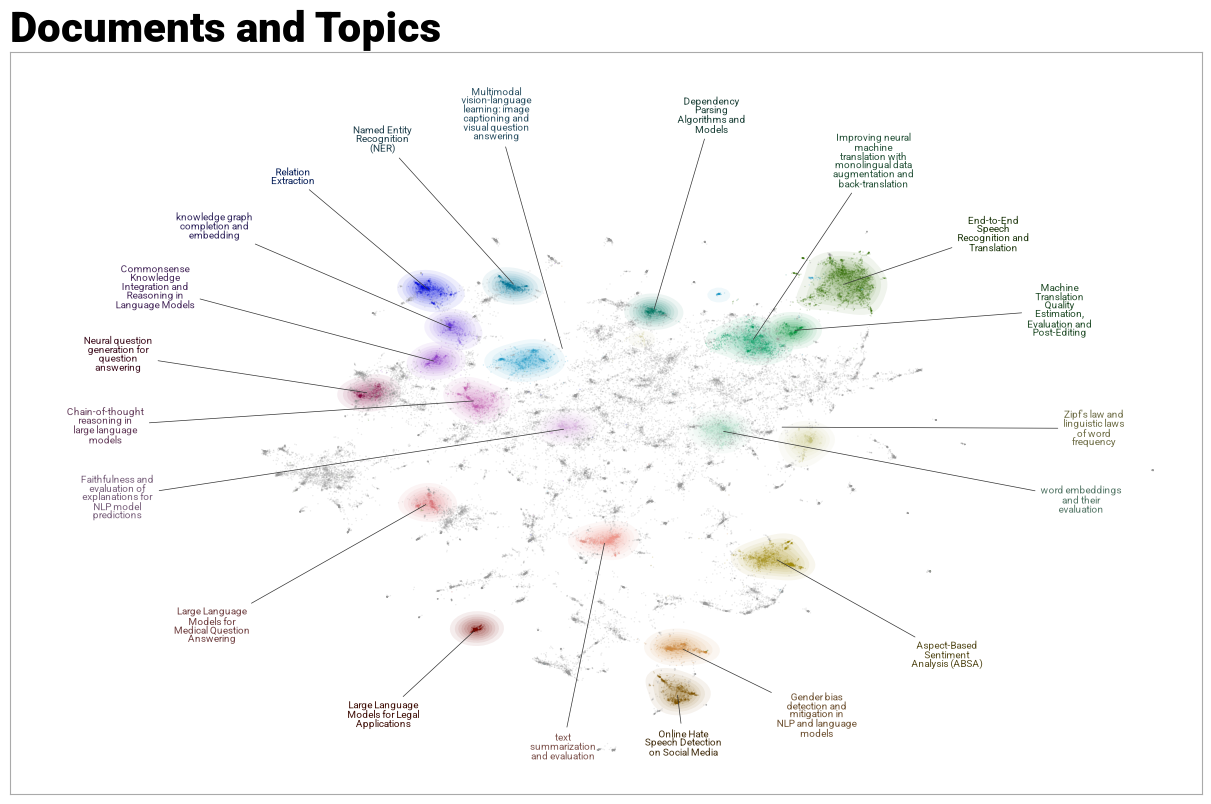

In [23]:
# 可视化主题和文档（bertopic 0.17.4 已移除 label_font_size 等参数，使用默认样式）
fig = topic_model.visualize_document_datamap(
    titles,
    topics=list(range(20)),
    reduced_embeddings=reduced_embeddings,
    width=1200,
)

<div align="center">
    <img src="./picture/5-24.jpg">
    <p>图5-24：可视化的前20个主题</p>
</div>

## 5.4 小结

在本章中，我们探讨了生成模型和表示模型如何在无监督学习领域发挥作用。尽管近年来监督方法（如分类）盛行，但无监督方法（如文本聚类）由于能够在无须预先标注的情况下基于语义内容对文本进行分组，仍然具有巨大潜力。

我们介绍了一个常见的文本聚类流程。首先将输入文本转换为数值表示，即嵌入向量。然后对这些嵌入向量进行降维，以简化高维数据，获得更好的聚类效果。最后，对降维后的嵌入向量应用聚类算法，来对输入文本进行聚类。通过手动查看这些簇，我们可以更好地理解每个簇包含哪些文档，以及如何解释这些簇。

为了免于手动查看，我们探索了BERTopic如何通过自动表示聚类的方法来扩展这个文本聚类流程。这种方法通常被称为主题建模，它试图在大量文档中发现主题。BERTopic通过结合c-TF-IDF的词袋方法生成这些主题表示，该方法根据词在簇中的相关性和在所有簇中的频率来给词加权。

BERTopic的一大优势在于其模块化特性。在BERTopic中，你可以自由选择流程中的任意模型，从而为同一主题创建多个视角的表示。我们探索了利用最大边际相关性和KeyBERTInspired来微调由c-TF-IDF生成的主题表示。此外，我们还使用了上一章介绍的生成式LLM（FLAN-T5和GPT-3.5）​，通过生成高度可解释的标签，进一步提高主题的可解释性。

在下一章中，我们将转换焦点，探索改进生成模型输出的常用方法——提示工程。